## Contextual (local) click embeddings using Word2Vec

In [1]:
from utils.ml import tokenize, load_data, data_dir, evaluate_clustering_model, vectorize
df = load_data(data_dir)
sequences, tokens = tokenize(df)

TOKENIZED DF:
+----+-----+---+-----+-------+----------+--------------------+
|year|month|day|order|country|session ID|            sequence|
+----+-----+---+-----+-------+----------+--------------------+
|2008|    4|  1|    9|     29|         1|[120, 168, 197, 8...|
|2008|    4|  1|   10|     29|         2|[143, 55, 183, 27...|
+----+-----+---+-----+-------+----------+--------------------+
only showing top 2 rows

TOKEN INFO: 
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|                     1|                     A5|     3|       2|                1|   43|      2|   1|  0|
|                     3|                    C30|     2|       4|                2|   28|      2|   2|  1|
+----------------------+----------------

### Word2Vec

In [2]:
melted_sequences = vectorize(sequences)

Word2Vec model not found. Refitting...
+---+----+-----+---+-------+----------+--------------------+
| id|year|month|day|country|session ID|              vector|
+---+----+-----+---+-------+----------+--------------------+
|120|2008|    4|  1|     29|         1|[0.07261090725660...|
|168|2008|    4|  1|     29|         1|[0.07725096493959...|
|197|2008|    4|  1|     29|         1|[-0.2250515967607...|
| 87|2008|    4|  1|     29|         1|[-0.1213048025965...|
| 39|2008|    4|  1|     29|         1|[0.00638763699680...|
+---+----+-----+---+-------+----------+--------------------+
only showing top 5 rows



### Let's try to cluster mean pooling

In [3]:
from pyspark.ml.stat import Summarizer
from pyspark.sql import functions as F
from pyspark.ml.feature import Normalizer
pooled = melted_sequences.groupBy("Session ID").agg(Summarizer.mean(F.col("vector")).alias("context"))
pooled.show(5)
normalized = Normalizer(inputCol="context", outputCol="context_norm").transform(pooled)
normalized.show(5)

+----------+--------------------+
|Session ID|             context|
+----------+--------------------+
|         1|[-0.0555383388160...|
|         2|[-0.2078013677150...|
|         3|[-0.2147030817965...|
|         4|[0.07546968013048...|
|         5|[0.20651231706142...|
+----------+--------------------+
only showing top 5 rows

+----------+--------------------+--------------------+
|Session ID|             context|        context_norm|
+----------+--------------------+--------------------+
|         1|[-0.0555383388160...|[-0.0814787609247...|
|         2|[-0.2078013677150...|[-0.2374678906542...|
|         3|[-0.2147030817965...|[-0.2046879483888...|
|         4|[0.07546968013048...|[0.05674760086056...|
|         5|[0.20651231706142...|[0.13299901083996...|
+----------+--------------------+--------------------+
only showing top 5 rows



In [4]:
results = {"K-Means": [], "Bisecting KMeans": []}
from pyspark.ml.clustering import BisectingKMeans, KMeans
results["K-Means"].append(evaluate_clustering_model(KMeans(maxIter=30), normalized , range(2, 21), features_col="context_norm", distance = "cosine"))
print("K-Means: done.")
results["Bisecting KMeans"].append(evaluate_clustering_model(BisectingKMeans(maxIter=50), normalized , range(2, 21), features_col="context_norm", distance = "cosine"))
print("Bi-Means: done.")

K-Means: done.
Bi-Means: done.


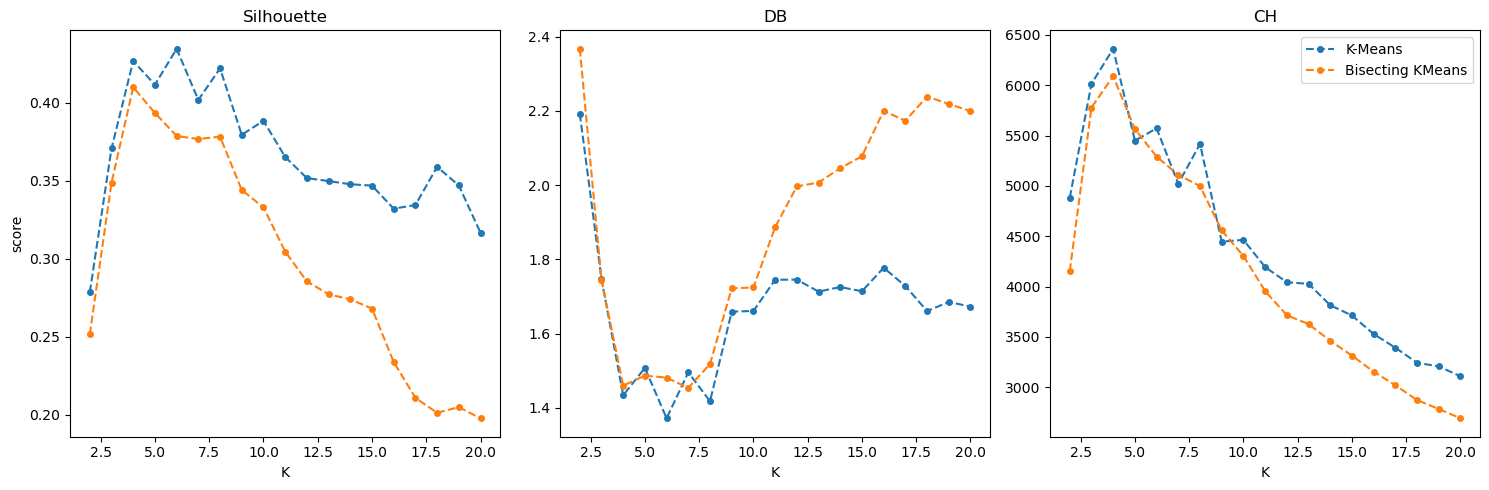

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
models = list(results.keys())
scores = ["Silhouette", "DB", "CH"]
for r in range(1):
    for m in models:
        ax[0].plot(results[m][r]["N_K"], results[m][r]["silouhette"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[1].plot(results[m][r]["N_K"], results[m][r]["davies_bouldin"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[2].plot(results[m][r]["N_K"], results[m][r]["calinski_harabasz"], label= m, linestyle = "--", marker = "o", markersize = 4)
    for c in range(3):
        ax[c].set_xlabel("K")
        if r == 0:
            ax[c].set_title(scores[c])
        if c == 0:
            ax[c].set_ylabel(f"score")
        if c == 2:
            ax[c].legend()
plt.tight_layout()
plt.show()